# Data Science Salary Analysis

___

## 1. Exploratory Data Analysis (EDA)

This project explores salary patterns in the data science industry using a dataset containing information about roles, experience levels, company locations and remote work.

The goal of this analysis is to understand the main factors influencing salaries in the data science field and identify patterns across experience levels, locations and time.

## 2. Objectives

- Understand salary distribution in data science roles
- Identify key factors influencing salaries
- Analyze geographic salary differences
- Explore trends over time

## 3. Libraries

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import plotly.express as px

import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

sns.set_theme(style="whitegrid")

plt.rcParams["figure.figsize"] = (10,6)
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 12

pd.set_option("display.max_columns", None)

## 4. Load Dataset

### Dataset Overview

In [2]:
df = pd.read_csv("/kaggle/input/datasets/ruchi798/data-science-job-salaries/ds_salaries.csv")

print("Dataset shape:", df.shape)
print("Unique job titles:", df["job_title"].nunique())
print("Countries represented:", df["company_location"].nunique())

df.head()
df.sample(5)

Dataset shape: (607, 12)
Unique job titles: 50
Countries represented: 50


,Unnamed: 0,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
180,180,2021,MI,FT,Big Data Engineer,1672000,INR,22611,IN,0,IN,L
161,161,2021,EX,FT,Head of Data Science,85000,USD,85000,RU,0,RU,M
518,518,2022,MI,FT,Data Scientist,115000,CHF,122346,CH,0,CH,L
584,584,2022,SE,FT,Data Analyst,105000,USD,105000,US,100,US,M
30,30,2020,MI,FT,Data Engineering Manager,51999,EUR,59303,DE,100,DE,S


## 5. Data Understanding

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 607 entries, 0 to 606
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Unnamed: 0          607 non-null    int64 
 1   work_year           607 non-null    int64 
 2   experience_level    607 non-null    object
 3   employment_type     607 non-null    object
 4   job_title           607 non-null    object
 5   salary              607 non-null    int64 
 6   salary_currency     607 non-null    object
 7   salary_in_usd       607 non-null    int64 
 8   employee_residence  607 non-null    object
 9   remote_ratio        607 non-null    int64 
 10  company_location    607 non-null    object
 11  company_size        607 non-null    object
dtypes: int64(5), object(7)
memory usage: 57.0+ KB


The dataset contains salary information for 607 data science roles across 50 different countries and 50 job titles.  
The majority of salaries are reported in USD after conversion, which allows for direct comparison across locations.

In [4]:
df.describe(include="all")

,Unnamed: 0,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
count,607.000000,607.000000,607,607,607,6.070000e+02,607,607.000000,607,607.00000,607,607
unique,NaN,NaN,4,4,50,NaN,17,NaN,57,NaN,50,3
top,NaN,NaN,SE,FT,Data Scientist,NaN,USD,NaN,US,NaN,US,M
freq,NaN,NaN,280,588,143,NaN,398,NaN,332,NaN,355,326
mean,303.000000,2021.405272,NaN,NaN,NaN,3.240001e+05,NaN,112297.869852,NaN,70.92257,NaN,NaN
std,175.370085,0.692133,NaN,NaN,NaN,1.544357e+06,NaN,70957.259411,NaN,40.70913,NaN,NaN
min,0.000000,2020.000000,NaN,NaN,NaN,4.000000e+03,NaN,2859.000000,NaN,0.00000,NaN,NaN
25%,151.500000,2021.000000,NaN,NaN,NaN,7.000000e+04,NaN,62726.000000,NaN,50.00000,NaN,NaN
50%,303.000000,2022.000000,NaN,NaN,NaN,1.150000e+05,NaN,101570.000000,NaN,100.00000,NaN,NaN
75%,454.500000,2022.000000,NaN,NaN,NaN,1.650000e+05,NaN,150000.000000,NaN,100.00000,NaN,NaN


## 6. Data Cleaning

The column "Unnamed: 0" is an index column created during dataset export and does not contain meaningful information for the analysis. It will therefore be removed.

In [5]:
df = df.drop(columns=["Unnamed: 0"])
df.head()

,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,2020,MI,FT,Data Scientist,70000,EUR,79833,DE,0,DE,L
1,2020,SE,FT,Machine Learning Scientist,260000,USD,260000,JP,0,JP,S
2,2020,SE,FT,Big Data Engineer,85000,GBP,109024,GB,50,GB,M
3,2020,MI,FT,Product Data Analyst,20000,USD,20000,HN,0,HN,S
4,2020,SE,FT,Machine Learning Engineer,150000,USD,150000,US,50,US,L


## Verify dataset structure after cleaning

In [6]:
df.shape

(607, 11)

In [7]:
df.columns

Index(['work_year', 'experience_level', 'employment_type', 'job_title',
       'salary', 'salary_currency', 'salary_in_usd', 'employee_residence',
       'remote_ratio', 'company_location', 'company_size'],
      dtype='object')

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 607 entries, 0 to 606
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   work_year           607 non-null    int64 
 1   experience_level    607 non-null    object
 2   employment_type     607 non-null    object
 3   job_title           607 non-null    object
 4   salary              607 non-null    int64 
 5   salary_currency     607 non-null    object
 6   salary_in_usd       607 non-null    int64 
 7   employee_residence  607 non-null    object
 8   remote_ratio        607 non-null    int64 
 9   company_location    607 non-null    object
 10  company_size        607 non-null    object
dtypes: int64(4), object(7)
memory usage: 52.3+ KB


In [9]:
df.describe(include="all")

,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
count,607.000000,607,607,607,6.070000e+02,607,607.000000,607,607.00000,607,607
unique,NaN,4,4,50,NaN,17,NaN,57,NaN,50,3
top,NaN,SE,FT,Data Scientist,NaN,USD,NaN,US,NaN,US,M
freq,NaN,280,588,143,NaN,398,NaN,332,NaN,355,326
mean,2021.405272,NaN,NaN,NaN,3.240001e+05,NaN,112297.869852,NaN,70.92257,NaN,NaN
std,0.692133,NaN,NaN,NaN,1.544357e+06,NaN,70957.259411,NaN,40.70913,NaN,NaN
min,2020.000000,NaN,NaN,NaN,4.000000e+03,NaN,2859.000000,NaN,0.00000,NaN,NaN
25%,2021.000000,NaN,NaN,NaN,7.000000e+04,NaN,62726.000000,NaN,50.00000,NaN,NaN
50%,2022.000000,NaN,NaN,NaN,1.150000e+05,NaN,101570.000000,NaN,100.00000,NaN,NaN
75%,2022.000000,NaN,NaN,NaN,1.650000e+05,NaN,150000.000000,NaN,100.00000,NaN,NaN


In [10]:
df["experience_level"].unique()

array(['MI', 'SE', 'EN', 'EX'], dtype=object)

In [11]:
df["employment_type"].unique()

array(['FT', 'CT', 'PT', 'FL'], dtype=object)

In [12]:
df.isna().sum()

work_year             0
experience_level      0
employment_type       0
job_title             0
salary                0
salary_currency       0
salary_in_usd         0
employee_residence    0
remote_ratio          0
company_location      0
company_size          0
dtype: int64

In [13]:
df[df.duplicated(keep=False)].sort_values(by=list(df.columns))

,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
119,2021,MI,FT,Data Engineer,200000,USD,200000,US,100,US,L
256,2021,MI,FT,Data Engineer,200000,USD,200000,US,100,US,L
181,2021,MI,FT,Data Scientist,76760,EUR,90734,DE,50,DE,L
217,2021,MI,FT,Data Scientist,76760,EUR,90734,DE,50,DE,L
367,2022,MI,FT,Data Analyst,58000,USD,58000,US,0,US,S
...,...,...,...,...,...,...,...,...,...,...,...
592,2022,SE,FT,Data Scientist,230000,USD,230000,US,100,US,M
372,2022,SE,FT,Machine Learning Engineer,164996,USD,164996,US,0,US,M
439,2022,SE,FT,Machine Learning Engineer,164996,USD,164996,US,0,US,M
371,2022,SE,FT,Machine Learning Engineer,189650,USD,189650,US,0,US,M


Duplicate rows were detected in the dataset. 
Since these records contain identical information across all variables, they are likely the result of dataset aggregation or export issues. 

Removing duplicates ensures that salary statistics are not artificially inflated.

In [14]:
df= df.drop_duplicates()
df.duplicated().sum()

np.int64(0)

In [15]:
df.shape

(565, 11)

In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 565 entries, 0 to 606
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   work_year           565 non-null    int64 
 1   experience_level    565 non-null    object
 2   employment_type     565 non-null    object
 3   job_title           565 non-null    object
 4   salary              565 non-null    int64 
 5   salary_currency     565 non-null    object
 6   salary_in_usd       565 non-null    int64 
 7   employee_residence  565 non-null    object
 8   remote_ratio        565 non-null    int64 
 9   company_location    565 non-null    object
 10  company_size        565 non-null    object
dtypes: int64(4), object(7)
memory usage: 53.0+ KB


## 7. Exploratory Data Analysis

This section explores salary patterns across different dimensions such as experience level, company size, geographic location and remote work arrangements.

### Salary by Experience Level

In [17]:
df.groupby("experience_level")["salary_in_usd"].describe()


,count,mean,std,min,25%,50%,75%,max
experience_level,,,,,,,,
EN,88.0,61643.318182,44395.541126,4000.0,27505.00,56500.0,85425.75,250000.0
EX,26.0,199392.038462,117071.255697,69741.0,130006.50,171437.5,233750.00,600000.0
MI,208.0,87792.995192,64118.971174,2859.0,47163.75,76940.0,112075.00,450000.0
SE,243.0,138374.880658,59955.965011,18907.0,99531.50,135000.0,171881.00,412000.0


In [18]:
df.groupby("experience_level")["salary_in_usd"].mean().sort_values()

experience_level
EN     61643.318182
MI     87792.995192
SE    138374.880658
EX    199392.038462
Name: salary_in_usd, dtype: float64

Salary distributions often contain extreme values that can distort the mean. 

For this reason, the median salary is used throughout this analysis as the primary measure of central tendency. The median provides a more robust estimate of typical compensation by reducing the influence of extreme values.

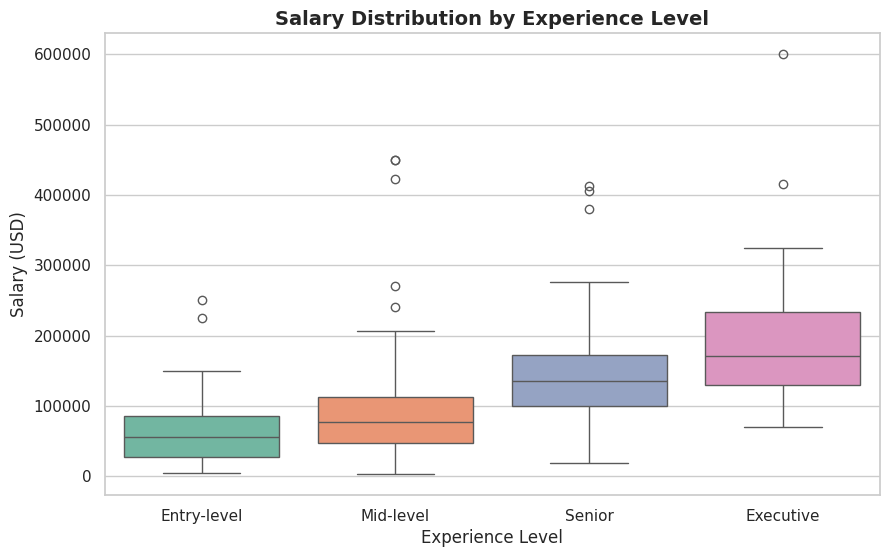

In [19]:
labels = {
    "EN": "Entry-level",
    "MI": "Mid-level",
    "SE": "Senior",
    "EX": "Executive"
}

df["experience_label"] = df["experience_level"].map(labels)

order = ["Entry-level","Mid-level","Senior","Executive"]

sns.boxplot(
    x="experience_label",
    y="salary_in_usd",
    data=df,
    order=order,
    palette="Set2"
)

plt.title("Salary Distribution by Experience Level")
plt.xlabel("Experience Level")
plt.ylabel("Salary (USD)")

plt.show()

In [20]:
df[df["salary_in_usd"] > 400000].shape

(7, 12)

In [21]:
df[df["salary_in_usd"] > 400000][["job_title","experience_level","company_location"]]

,job_title,experience_level,company_location
33,Research Scientist,MI,US
63,Data Scientist,SE,US
97,Financial Data Analyst,MI,US
157,Applied Machine Learning Scientist,MI,US
225,Principal Data Scientist,EX,US
252,Principal Data Engineer,EX,US
523,Data Analytics Lead,SE,US


Several salaries above 400,000 USD appear in the dataset. 
Although these values may initially appear as outliers, they correspond to senior or executive-level roles such as Principal Data Scientist or Data Analytics Lead.

Therefore, these observations are retained in the dataset as they represent valid high-compensation positions rather than data errors.

### Salary by Employment Type

In [22]:
df["employment_type"].value_counts()

employment_type
FT    546
PT     10
CT      5
FL      4
Name: count, dtype: int64

The dataset is heavily dominated by full-time positions (546 out of 565 observations, ~96%).
Other employment types such as part-time, contract, and freelance have extremely small sample sizes.

Due to this imbalance, analyzing salary differences across employment types would not provide reliable insights. Therefore, this variable will not be explored further in the salary analysis.

### Salary by Company Size

In [23]:
df["company_size"].value_counts()

company_size
M    290
L    193
S     82
Name: count, dtype: int64

In [24]:
df["company_size"].value_counts(normalize=True)

company_size
M    0.513274
L    0.341593
S    0.145133
Name: proportion, dtype: float64

All company size categories have a sufficient number of observations to allow meaningful comparison. Medium-sized companies represent the largest proportion of the dataset (≈51%), followed by large companies (≈34%) and small companies (≈14%).

Although the groups are not perfectly balanced, the sample sizes are still large enough to compare salary distributions across company sizes.

In [25]:
df.groupby("company_size")["salary_in_usd"].median()

company_size
L    100000.0
M    109640.0
S     65511.0
Name: salary_in_usd, dtype: float64

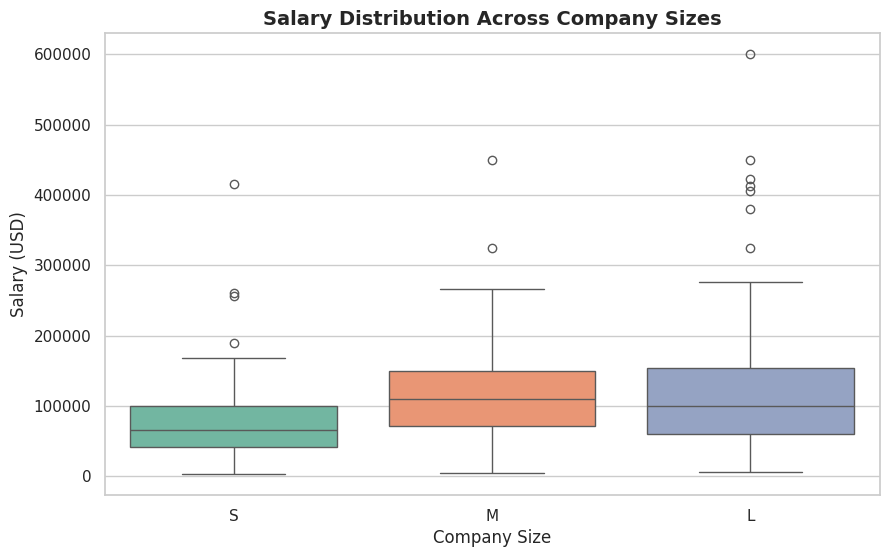

In [26]:
order= ["S", "M", "L"]

sns.boxplot(
    x="company_size",
    y="salary_in_usd",
    data=df,
    order=order,
    palette="Set2"
)

plt.title("Salary Distribution Across Company Sizes")
plt.xlabel("Company Size")
plt.ylabel("Salary (USD)")

plt.show()

### Salary by Company Location

Company location is expected to have a strong influence on salaries. Compensation in data-related roles often varies significantly across countries due to differences in cost of living, labor markets, and demand for skilled professionals.

### 1. Global geographic overview

### Prepare country names for mapping

In [27]:
country_map = {
"US":"United States",
"GB":"United Kingdom",
"CA":"Canada",
"DE":"Germany",
"IN":"India",
"FR":"France",
"ES":"Spain",
"GR":"Greece",
"JP":"Japan",
"NL":"Netherlands",
"PT":"Portugal",
"PL":"Poland",
"AT":"Austria",
"MX":"Mexico",
"DK":"Denmark",
"AE":"United Arab Emirates",
"PK":"Pakistan",
"LU":"Luxembourg",
"TR":"Turkey",
"BR":"Brazil",
"AU":"Australia"
}

df["country_name"] = df["company_location"].map(country_map)

### Keep original code if country not in the dictionary

In [28]:
df["country_name"] = df["country_name"].fillna(df["company_location"])

In [29]:
salary_by_country = (
    df.groupby("country_name", as_index=False)["salary_in_usd"]
      .median()
      .sort_values("salary_in_usd", ascending=False)
)

fig = px.choropleth(
    salary_by_country,
    locations="country_name",
    locationmode="country names",
    color="salary_in_usd",
    color_continuous_scale="Viridis",
    projection="natural earth",
    title="Median Data Science Salary by Country"
)

fig.update_traces(
    hovertemplate="<b>%{location}</b><br>Median salary: %{z:,.0f} USD<extra></extra>"
)

fig.update_geos(
    showcountries=True,
    countrycolor="white",
    showcoastlines=True,
    coastlinecolor="gray",
    showland=True,
    landcolor="rgb(235,235,235)",
    showocean=True,
    oceancolor="rgb(210,230,255)"
)

fig.update_layout(
    title=dict(
        text="Median Data Science Salary by Country",
        x=0.5,
        xanchor="center",
        font=dict(size=22)
    ),
    coloraxis_colorbar=dict(title="Median Salary (USD)"),
    margin=dict(l=0, r=0, t=80, b=0),
    height=650
)

fig.write_html("salary_map.html")

from IPython.display import IFrame
IFrame("salary_map.html", width=900, height=600)

Several regions appear without color because the dataset does not contain observations for those countries. 

This highlights how data science roles are concentrated in specific regions of the world, particularly in North America and Europe.

### 2. Country distribution in the dataset

In [30]:
df["company_location"].unique()

array(['DE', 'JP', 'GB', 'HN', 'US', 'HU', 'NZ', 'FR', 'IN', 'PK', 'CN',
       'GR', 'AE', 'NL', 'MX', 'CA', 'AT', 'NG', 'ES', 'PT', 'DK', 'IT',
       'HR', 'LU', 'PL', 'SG', 'RO', 'IQ', 'BR', 'BE', 'UA', 'IL', 'RU',
       'MT', 'CL', 'IR', 'CO', 'MD', 'KE', 'SI', 'CH', 'VN', 'AS', 'TR',
       'CZ', 'DZ', 'EE', 'MY', 'AU', 'IE'], dtype=object)

In [31]:
df["company_location"].nunique()

50

In [32]:
df["company_location"].value_counts()

company_location
US    318
GB     46
CA     28
DE     27
IN     24
FR     15
ES     14
GR     10
JP      6
NL      4
PT      4
PL      4
AT      4
MX      3
DK      3
AE      3
PK      3
LU      3
TR      3
BR      3
AU      3
RU      2
CN      2
CH      2
BE      2
NG      2
SI      2
IT      2
CZ      2
NZ      1
HU      1
HN      1
SG      1
HR      1
MT      1
IL      1
UA      1
RO      1
IQ      1
MD      1
CL      1
IR      1
VN      1
KE      1
CO      1
AS      1
DZ      1
EE      1
MY      1
IE      1
Name: count, dtype: int64

In [33]:
df["company_location"].value_counts(normalize=True)

company_location
US    0.562832
GB    0.081416
CA    0.049558
DE    0.047788
IN    0.042478
FR    0.026549
ES    0.024779
GR    0.017699
JP    0.010619
NL    0.007080
PT    0.007080
PL    0.007080
AT    0.007080
MX    0.005310
DK    0.005310
AE    0.005310
PK    0.005310
LU    0.005310
TR    0.005310
BR    0.005310
AU    0.005310
RU    0.003540
CN    0.003540
CH    0.003540
BE    0.003540
NG    0.003540
SI    0.003540
IT    0.003540
CZ    0.003540
NZ    0.001770
HU    0.001770
HN    0.001770
SG    0.001770
HR    0.001770
MT    0.001770
IL    0.001770
UA    0.001770
RO    0.001770
IQ    0.001770
MD    0.001770
CL    0.001770
IR    0.001770
VN    0.001770
KE    0.001770
CO    0.001770
AS    0.001770
DZ    0.001770
EE    0.001770
MY    0.001770
IE    0.001770
Name: proportion, dtype: float64

Many countries appear only a few times in the dataset. To reduce visual noise while still preserving the information, countries with fewer than 5 observations are grouped into a single category called “Other”.

### 3. Top countries comparison

In [34]:
country_counts = df["company_location"].value_counts()

major_countries = country_counts[country_counts >= 5].index

df["country_grouped"] = df["company_location"]
df.loc[~df["company_location"].isin(major_countries), "country_grouped"] = "Other"

df["country_grouped"].value_counts()

country_grouped
US       318
Other     77
GB        46
CA        28
DE        27
IN        24
FR        15
ES        14
GR        10
JP         6
Name: count, dtype: int64

Among the most represented countries, the United States shows the highest median salary by a significant margin. 

In contrast, India presents the lowest median salary, which may reflect differences in labor markets, cost of living, and industry maturity.

In [35]:
top_countries = df["company_location"].value_counts().head(10).index

In [36]:
df_top = df[df["company_location"].isin(top_countries)]

df_top["company_location"].value_counts()

company_location
US    318
GB     46
CA     28
DE     27
IN     24
FR     15
ES     14
GR     10
JP      6
NL      4
Name: count, dtype: int64

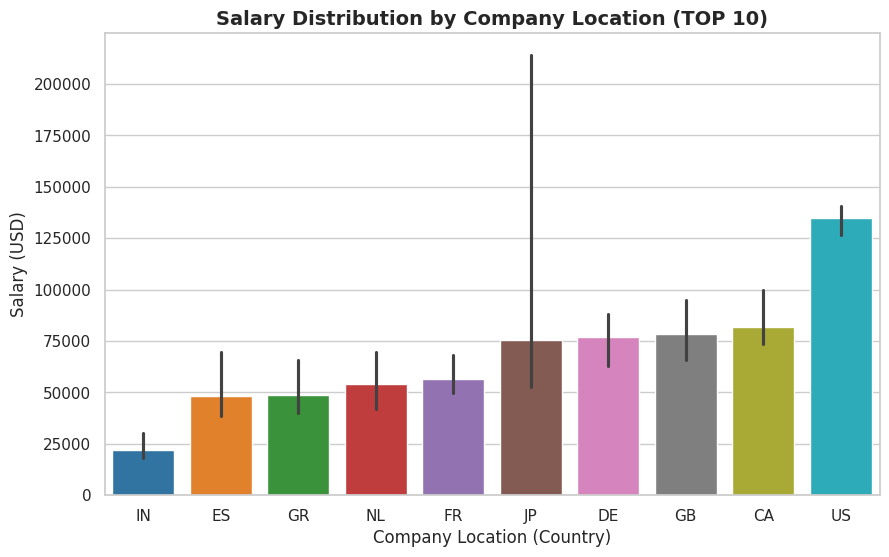

In [37]:
order = df_top.groupby("company_location")["salary_in_usd"].median().sort_values().index

sns.barplot(x= "company_location",
           y= "salary_in_usd",
           data= df_top,
           estimator=np.median,
           order=order,
           palette="tab10"
           )

plt.title("Salary Distribution by Company Location (TOP 10)")
plt.xlabel("Company Location (Country)")
plt.ylabel("Salary (USD)")

plt.show()

The dataset shows that the highest median salaries are concentrated in companies located in the United States, which also represents the largest share of observations.

In contrast, companies located in India show the lowest median salary among the top represented countries, remaining below 25,000 USD.

### Salary by Remote Work

The variable `remote_ratio` represents the proportion of remote work:

- 0 → On-site
- 50 → Hybrid
- 100 → Remote

In [38]:
df["remote_ratio"].unique()

array([  0,  50, 100])

In [39]:
df["remote_ratio"].value_counts()

remote_ratio
100    346
0      121
50      98
Name: count, dtype: int64

In [40]:
df["remote_type"]= df["remote_ratio"].map({
    0: "On-site",
    50: "Hybrid",
    100: "Remote"
})

df["remote_type"].value_counts()

remote_type
Remote     346
On-site    121
Hybrid      98
Name: count, dtype: int64

Remote work is the most common arrangement in the dataset, representing the majority of observations.

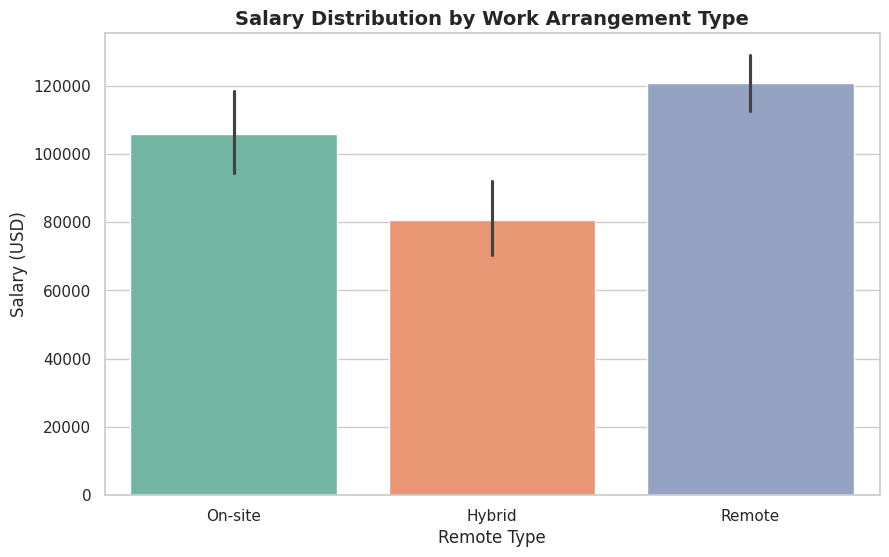

In [41]:
order= ["On-site", "Hybrid", "Remote"]

sns.barplot(x= "remote_type",
            y= "salary_in_usd",
            data= df,
            order=order,
            palette="Set2",
            )

plt.title("Salary Distribution by Work Arrangement Type")
plt.xlabel("Remote Type")
plt.ylabel("Salary (USD)")

plt.show()

Remote roles show the highest median salary among the three work arrangements. 
However, this difference should be interpreted carefully, as remote positions may also be associated with higher-paying companies, senior roles, or specific geographic markets.

Therefore, remote work itself may not be the sole driver of higher salaries.

### Salary by Job Title

In [42]:
df["job_title"].nunique()

50

In [43]:
df["job_title"].unique()

array(['Data Scientist', 'Machine Learning Scientist',
       'Big Data Engineer', 'Product Data Analyst',
       'Machine Learning Engineer', 'Data Analyst', 'Lead Data Scientist',
       'Business Data Analyst', 'Lead Data Engineer', 'Lead Data Analyst',
       'Data Engineer', 'Data Science Consultant', 'BI Data Analyst',
       'Director of Data Science', 'Research Scientist',
       'Machine Learning Manager', 'Data Engineering Manager',
       'Machine Learning Infrastructure Engineer', 'ML Engineer',
       'AI Scientist', 'Computer Vision Engineer',
       'Principal Data Scientist', 'Data Science Manager', 'Head of Data',
       '3D Computer Vision Researcher', 'Data Analytics Engineer',
       'Applied Data Scientist', 'Marketing Data Analyst',
       'Cloud Data Engineer', 'Financial Data Analyst',
       'Computer Vision Software Engineer',
       'Director of Data Engineering', 'Data Science Engineer',
       'Principal Data Engineer', 'Machine Learning Developer',
       

In [44]:
df["job_title"].value_counts()

job_title
Data Scientist                              130
Data Engineer                               121
Data Analyst                                 82
Machine Learning Engineer                    39
Research Scientist                           16
Data Science Manager                         12
Data Architect                               11
Machine Learning Scientist                    8
Big Data Engineer                             8
Director of Data Science                      7
AI Scientist                                  7
Principal Data Scientist                      7
Data Science Consultant                       7
Data Analytics Manager                        7
BI Data Analyst                               6
Computer Vision Engineer                      6
ML Engineer                                   6
Lead Data Engineer                            6
Applied Data Scientist                        5
Business Data Analyst                         5
Data Engineering Manager      

Job titles in the dataset are highly diverse, with more than 50 unique roles. 

To improve readability, the analysis focuses on the 10 most frequent job titles.

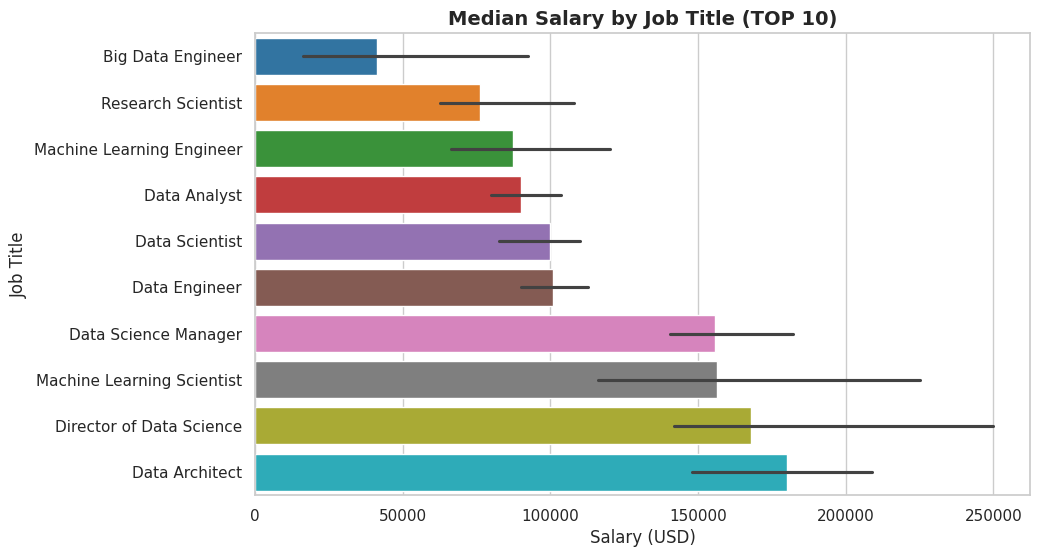

In [45]:
top_jobs = df["job_title"].value_counts().head(10).index

df_jobs = df[df["job_title"].isin(top_jobs)]

order = df_jobs.groupby("job_title")["salary_in_usd"].median().sort_values().index

sns.barplot(
    x="salary_in_usd",
    y="job_title",
    data=df_jobs,
    estimator=np.median,
    order=order,
    palette="tab10"
)

plt.title("Median Salary by Job Title (TOP 10)")
plt.xlabel("Salary (USD)")
plt.ylabel("Job Title")

plt.show()

### Salary Distribution Over Time

In [46]:
df["work_year"].unique()

array([2020, 2021, 2022])

In [47]:
df["work_year"].value_counts()

work_year
2022    278
2021    215
2020     72
Name: count, dtype: int64

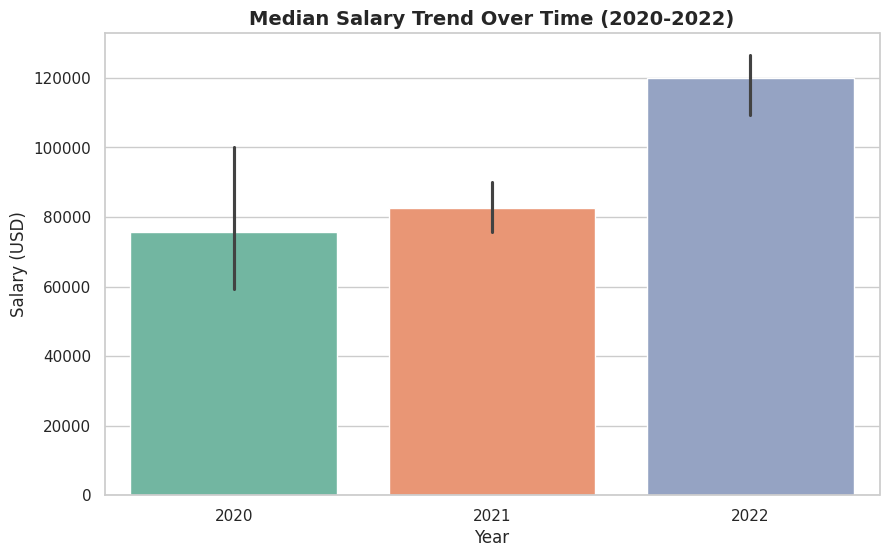

In [48]:
order= [2020, 2021, 2022]

sns.barplot(x="work_year",
           y="salary_in_usd",
           data=df,
           order=order,
           estimator=np.median,
           palette="Set2"
           )

plt.title("Median Salary Trend Over Time (2020-2022)")
plt.xlabel("Year")
plt.ylabel("Salary (USD)")

plt.show()


Median salaries appear to increase between 2020 and 2022. 
This trend may reflect the rapid expansion of the data science field and the increasing demand for data professionals in recent years.

### Experience Distribution Over Time

In [49]:
df_experience_by_year= df.groupby("work_year")["experience_level"].value_counts()

df_experience_by_year

work_year  experience_level
2020       MI                   32
           EN                   20
           SE                   18
           EX                    2
2021       MI                   88
           SE                   69
           EN                   47
           EX                   11
2022       SE                  156
           MI                   88
           EN                   21
           EX                   13
Name: count, dtype: int64

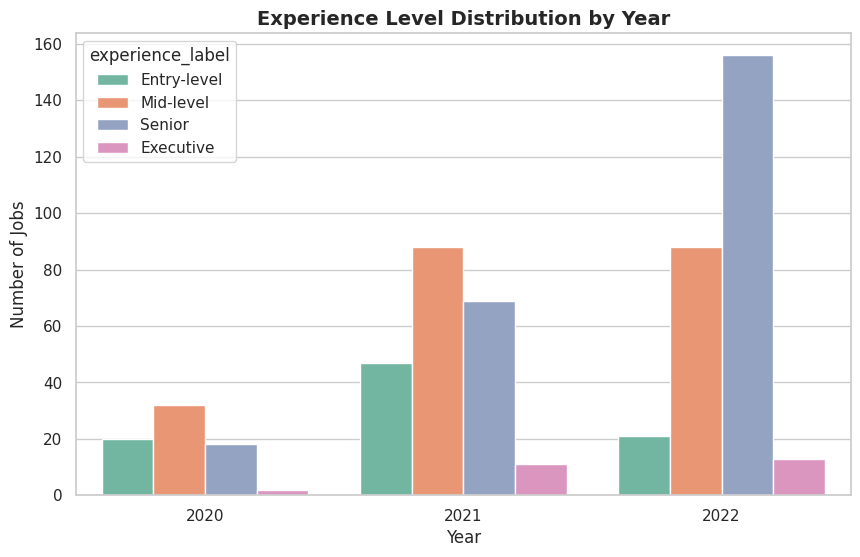

In [50]:
order = ["Entry-level", "Mid-level", "Senior", "Executive"]

sns.countplot(x="work_year",
             hue= "experience_label",
             data= df,
             hue_order=order,
             palette="Set2"
             )

plt.title("Experience Level Distribution by Year")
plt.xlabel("Year")
plt.ylabel("Number of Jobs")

plt.show()

The distribution of experience levels shows a strong increase in senior (SE) roles in 2022. This shift may partially explain the increase in median salaries observed in previous sections. Meanwhile, mid-level (MI) positions remain relatively stable, while entry-level (EN) roles appear to decrease compared to 2021. However, the dataset also grows significantly over time, which may influence these patterns.

### Salary by Experience Level Across Years

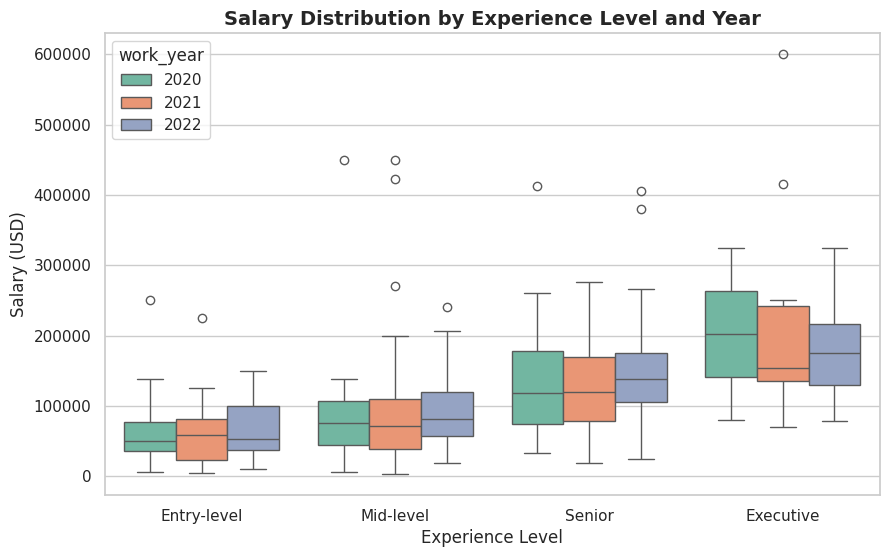

In [51]:
sns.boxplot(x="experience_label",
           y="salary_in_usd",
           hue="work_year",
           data=df,
           order=order,
           palette="Set2"
           )

plt.title("Salary Distribution by Experience Level and Year")
plt.xlabel("Experience Level")
plt.ylabel("Salary (USD)")

plt.show()

### Salary Patterns by Experience, Remote Work and Company Size

In [52]:
bubble_data = (
    df.groupby(["experience_label", "remote_type", "company_size"], as_index=False)
      ["salary_in_usd"].median()
)

fig = px.scatter(
    bubble_data,
    x="experience_label",
    y="salary_in_usd",
    size="salary_in_usd",
    color="remote_type",
    facet_col="company_size",
    size_max=40,
    title="Salary Patterns by Experience Level, Remote Work and Company Size",
    labels={
        "salary_in_usd": "Median Salary (USD)",
        "experience_label": "Experience Level",
        "remote_type": "Work Arrangement",
        "company_size": "Company Size"
    }
)

fig.update_layout(height=600)

fig.write_html("bubble_chart.html")

from IPython.display import IFrame
IFrame("bubble_chart.html", width=900, height=600)

This visualization highlights how salary levels increase with experience across all company sizes. 

It also suggests that remote roles tend to appear more frequently in higher salary ranges, particularly for senior-level positions. However, the relationship between remote work and salary may also be influenced by company size and geographic factors.

## 9. Key Insights

1. Experience level is the strongest driver of salary differences. Median compensation increases substantially from entry-level to executive roles.

2. The United States dominates the dataset both in number of observations and salary levels, showing significantly higher median compensation compared to other countries.

3. Medium-sized companies offer the highest median salaries in the dataset, slightly surpassing large organizations.

4. Remote work arrangements are associated with higher median salaries, although this may be influenced by other factors such as company location or seniority.

5. Median salaries show a consistent upward trend between 2020 and 2022, reflecting the rapid growth of the data science industry.

## 10. Conclusion

This analysis explored salary patterns in the data science industry using a dataset covering multiple countries, job titles and work arrangements.

The results highlight the strong influence of experience level, company location and remote work on salary levels. In particular, senior and executive roles command significantly higher compensation, while the United States stands out as the highest-paying market in the dataset.

Overall, the findings reflect the rapid expansion of the data science field and the increasing demand for experienced professionals.